<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/modulation_ASK_FASK_PSK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 Técnicas de Modulação Digital
### Explicação preparada com auxílio do LLM Claude.
## ASK · FSK · PSK

---

A **modulação** é o processo de modificar uma **portadora** (onda senoidal de alta frequência) para transportar informação digital (bits 0 e 1).

| Técnica | O que muda na portadora | Parâmetro alterado |
|---------|------------------------|--------------------|
| **ASK** | Amplitude Shift Keying | Amplitude |
| **FSK** | Frequency Shift Keying | Frequência |
| **PSK** | Phase Shift Keying     | Fase |

> 💡 **Portadora:** $s(t) = A \cdot \cos(2\pi f t + \phi)$  
> Cada técnica modifica apenas **um** dos parâmetros: $A$, $f$ ou $\phi$.

## ⚙️ Instalação e Importações

In [ ]:
# Instala dependências (caso necessário no Colab)
# !pip install numpy matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 🔧 Parâmetros Globais da Simulação

Definimos aqui a **sequência de bits**, a **frequência da portadora** e a **taxa de símbolo** usadas em todos os exemplos.

In [ ]:
# ── Sequência de bits de exemplo ──────────────────────────────
bits = np.array([1, 0, 1, 1, 0, 1, 0, 0])
n_bits = len(bits)

# ── Parâmetros de tempo ───────────────────────────────────────
bit_duration = 1.0          # duração de cada bit (s)
samples_per_bit = 500       # amostras por bit
fs = samples_per_bit        # taxa de amostragem (Hz)

t_bit = np.linspace(0, bit_duration, samples_per_bit, endpoint=False)
t_total = np.linspace(0, n_bits * bit_duration, n_bits * samples_per_bit, endpoint=False)

# ── Portadora ─────────────────────────────────────────────────
fc = 8.0                    # frequência da portadora (Hz)

# ── Sinal de dados (NRZ) ──────────────────────────────────────
data_signal = np.repeat(bits, samples_per_bit).astype(float)

print(f'Bits:              {bits}')
print(f'Duração total:     {n_bits * bit_duration:.1f} s')
print(f'Frequência portadora: {fc} Hz')
print(f'Amostras totais:   {len(t_total)}')

Bits:              [1 0 1 1 0 1 0 0]
Duração total:     8.0 s
Frequência portadora: 8.0 Hz
Amostras totais:   4000


---
## 1️⃣ ASK — Amplitude Shift Keying

Na ASK, a **amplitude** da portadora muda de acordo com o bit transmitido:

$$
s_{ASK}(t) = A(t) \cdot \cos(2\pi f_c t)
$$

onde:
- $A(t) = A_1$ quando bit = **1**
- $A(t) = A_0$ quando bit = **0** (frequentemente $A_0 = 0$ → OOK)

**OOK (On-Off Keying):** caso especial onde bit 0 → portadora desligada.

| Vantagem | Desvantagem |
|----------|-------------|
| Simples de implementar | Muito sensível a ruído e atenuação |
| Baixo custo | Baixa eficiência espectral |

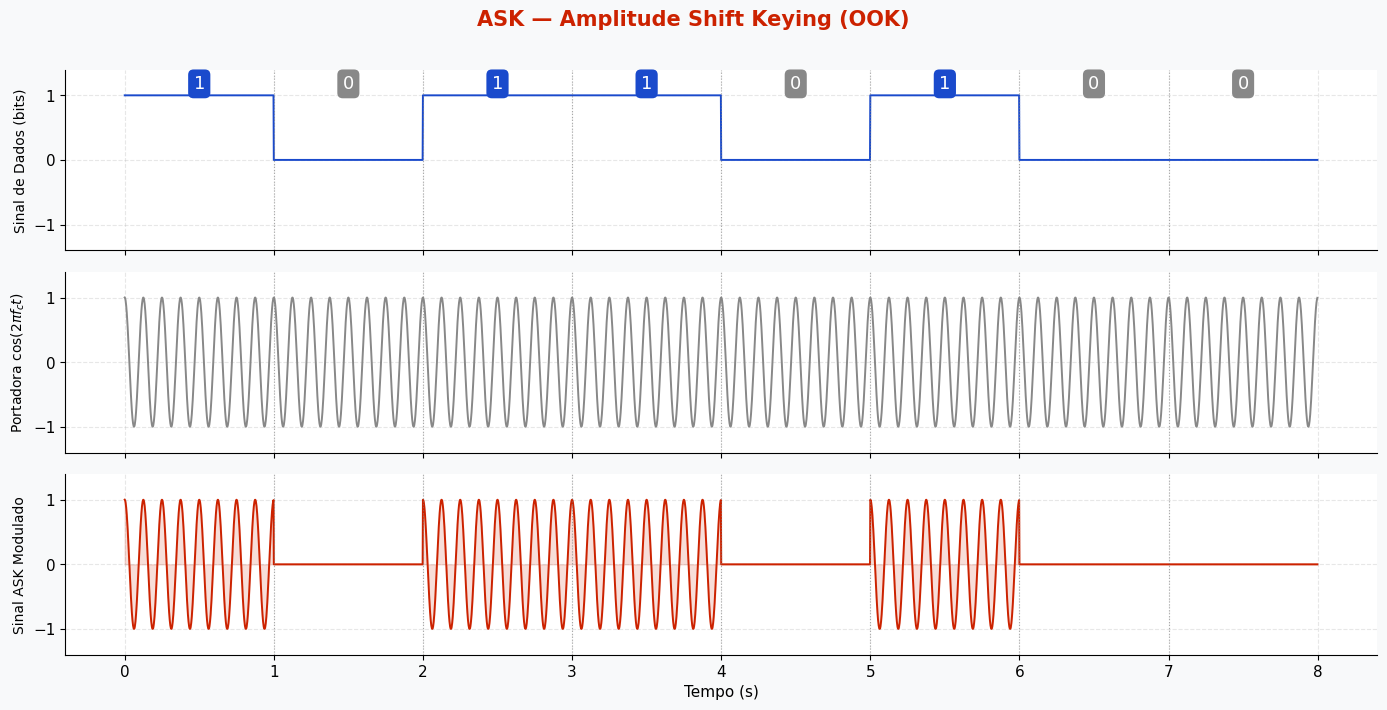

✅ Sinal ASK gerado!


In [ ]:
# ── Geração do sinal ASK (OOK) ────────────────────────────────
A1 = 1.0   # amplitude para bit 1
A0 = 0.0   # amplitude para bit 0 (OOK)

carrier = np.cos(2 * np.pi * fc * t_total)
amplitude_env = np.where(data_signal == 1, A1, A0)
ask_signal = amplitude_env * carrier

# ── Figura ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle('ASK — Amplitude Shift Keying (OOK)', fontsize=15, fontweight='bold', color='#cc2200', y=1.01)

colors = ['#1a4acc', '#888888', '#cc2200']
titles = ['Sinal de Dados (bits)', 'Portadora $\\cos(2\\pi f_c t)$', 'Sinal ASK Modulado']
signals = [data_signal, carrier, ask_signal]

for ax, sig, title, color in zip(axes, signals, titles, colors):
    ax.plot(t_total, sig, color=color, linewidth=1.4)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(-1.4, 1.4)
    ax.yaxis.set_label_position('left')
    # Bit boundaries
    for i in range(1, n_bits):
        ax.axvline(x=i * bit_duration, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    # Bit labels on top axis
    if ax == axes[0]:
        for i, b in enumerate(bits):
            ax.text(i + 0.5, 1.1, str(b), ha='center', fontsize=13,
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='#1a4acc' if b == 1 else '#888888',
                              edgecolor='none'))

# Fill under ASK signal for visual clarity
axes[2].fill_between(t_total, ask_signal, 0, alpha=0.15, color='#cc2200')

axes[2].set_xlabel('Tempo (s)', fontsize=11)
plt.tight_layout()
plt.savefig('ask_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sinal ASK gerado!')

---
## 2️⃣ FSK — Frequency Shift Keying

Na FSK, a **frequência** da portadora muda de acordo com o bit:

$$
s_{FSK}(t) = A \cdot \cos\bigl(2\pi f(t)\, t\bigr)
$$

onde:
- $f(t) = f_1$ quando bit = **1** (mark frequency)
- $f(t) = f_0$ quando bit = **0** (space frequency)

O **desvio de frequência** $\Delta f = f_1 - f_0$ determina a separação entre símbolos.

| Vantagem | Desvantagem |
|----------|-------------|
| Mais resistente a ruído que ASK | Ocupa mais largura de banda |
| Amplitude constante (sem distorção por canal) | Mais complexo que ASK |

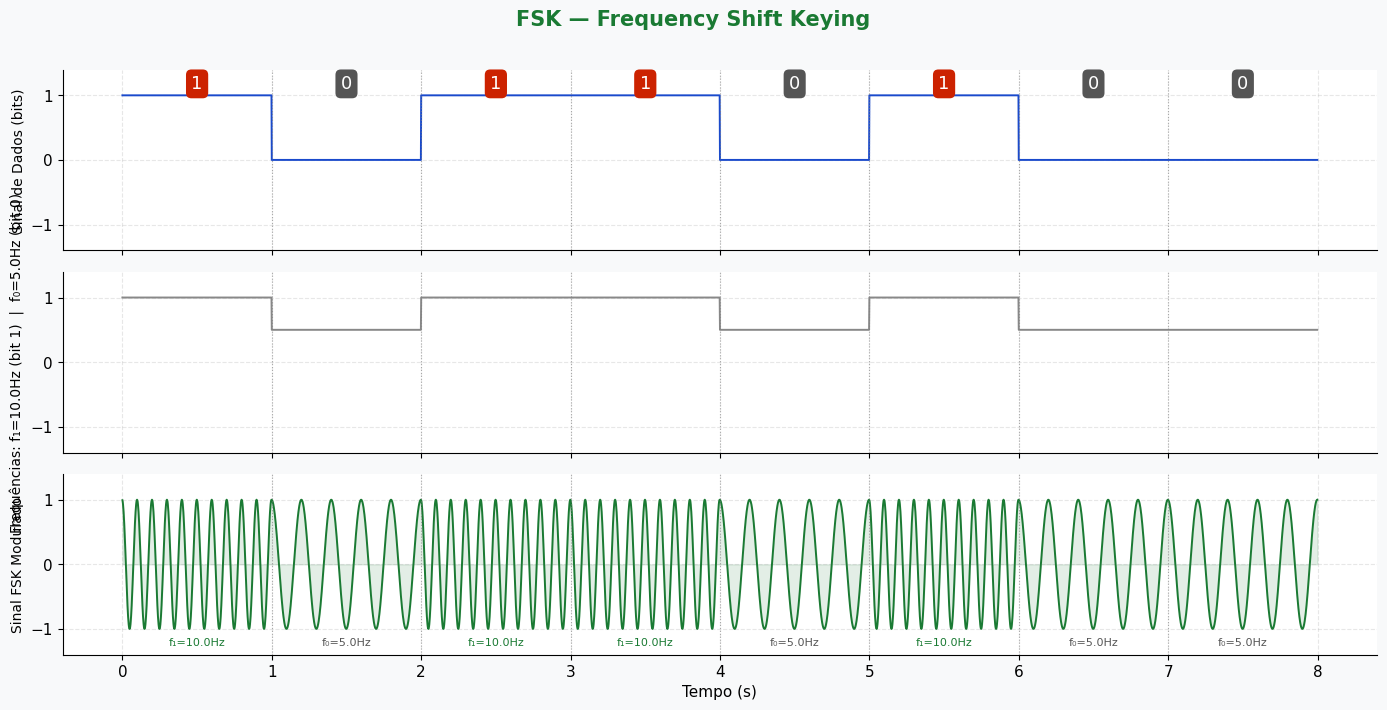

✅ Sinal FSK gerado!


In [ ]:
# ── Geração do sinal FSK ──────────────────────────────────────
f1 = 10.0   # frequência para bit 1 (mark)
f0 = 5.0    # frequência para bit 0 (space)

freq_env = np.where(data_signal == 1, f1, f0)

# Integração de fase para continuidade
phase = 2 * np.pi * np.cumsum(freq_env) / fs
fsk_signal = np.cos(phase)

# ── Figura ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle('FSK — Frequency Shift Keying', fontsize=15, fontweight='bold', color='#1a7a33', y=1.01)

colors_fsk = ['#1a4acc', '#888888', '#1a7a33']
titles_fsk = ['Sinal de Dados (bits)', f'Frequências: f₁={f1}Hz (bit 1)  |  f₀={f0}Hz (bit 0)', 'Sinal FSK Modulado']
signals_fsk = [data_signal, freq_env / max(f1, f0), fsk_signal]

for ax, sig, title, color in zip(axes, signals_fsk, titles_fsk, colors_fsk):
    ax.plot(t_total, sig, color=color, linewidth=1.4)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(-1.4, 1.4)
    for i in range(1, n_bits):
        ax.axvline(x=i * bit_duration, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    if ax == axes[0]:
        for i, b in enumerate(bits):
            ax.text(i + 0.5, 1.1, str(b), ha='center', fontsize=13,
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='#cc2200' if b == 1 else '#555555',
                              edgecolor='none'))

# Annotate frequency regions on FSK signal
for i, b in enumerate(bits):
    freq_label = f'f₁={f1}Hz' if b == 1 else f'f₀={f0}Hz'
    axes[2].text(i + 0.5, -1.25, freq_label, ha='center', fontsize=8,
                 color='#1a7a33' if b == 1 else '#555555')

axes[2].fill_between(t_total, fsk_signal, 0, alpha=0.12, color='#1a7a33')
axes[2].set_xlabel('Tempo (s)', fontsize=11)
plt.tight_layout()
plt.savefig('fsk_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sinal FSK gerado!')

---
## 3️⃣ PSK — Phase Shift Keying

Na PSK, a **fase** da portadora muda de acordo com o bit:

$$
s_{PSK}(t) = A \cdot \cos\bigl(2\pi f_c t + \phi(t)\bigr)
$$

No caso mais simples, **BPSK (Binary PSK)**:
- $\phi(t) = 0°$ quando bit = **1**
- $\phi(t) = 180°$ quando bit = **0** → inversão de fase

| Vantagem | Desvantagem |
|----------|-------------|
| Melhor eficiência de banda que FSK | Receptor mais complexo (precisa de referência de fase) |
| Boa imunidade a ruído | Sensível a distorções de fase no canal |

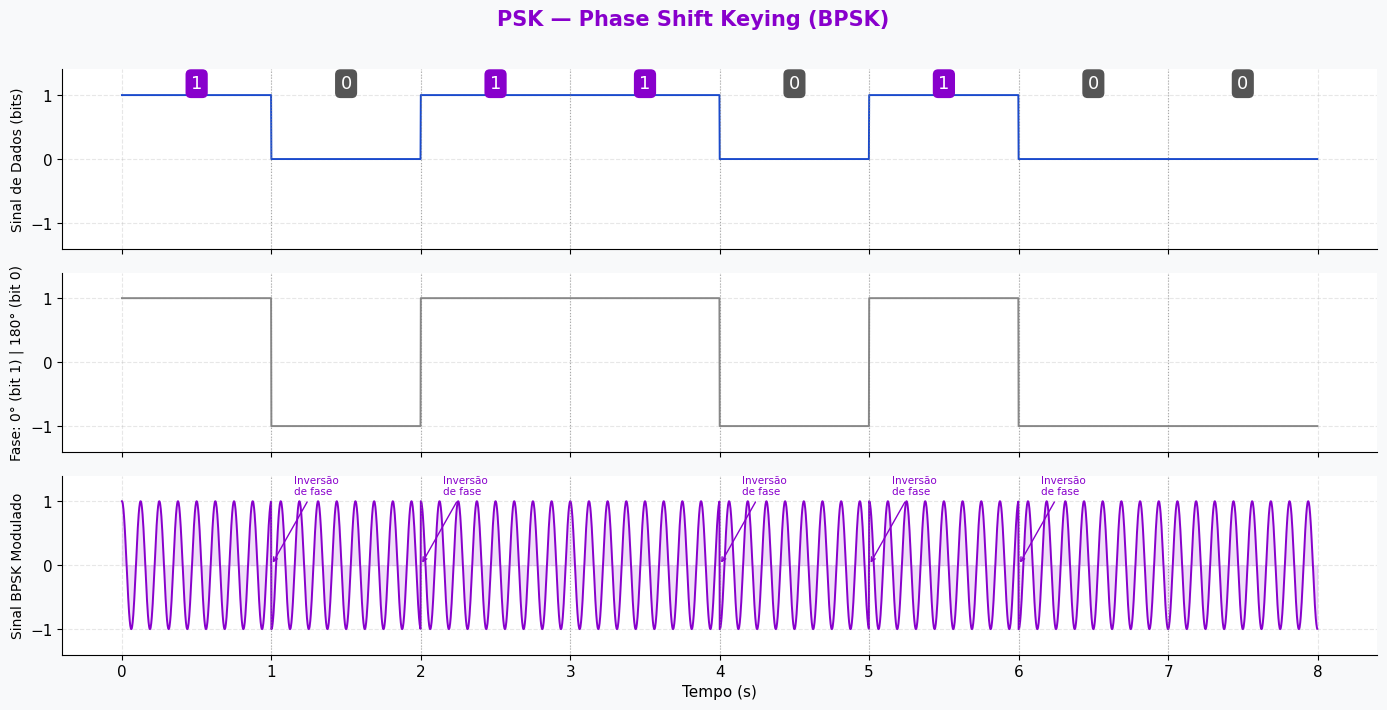

✅ Sinal PSK gerado!


In [ ]:
# ── Geração do sinal BPSK ─────────────────────────────────────
# Bit 1 → fase 0°, Bit 0 → fase 180° (multiplicar por -1)
bpsk_env = np.where(data_signal == 1, 1.0, -1.0)
bpsk_signal = bpsk_env * np.cos(2 * np.pi * fc * t_total)

# ── Figura ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle('PSK — Phase Shift Keying (BPSK)', fontsize=15, fontweight='bold', color='#8800cc', y=1.01)

colors_psk = ['#1a4acc', '#888888', '#8800cc']
titles_psk = ['Sinal de Dados (bits)', 'Fase: 0° (bit 1) | 180° (bit 0)', 'Sinal BPSK Modulado']
signals_psk = [data_signal, bpsk_env, bpsk_signal]

for ax, sig, title, color in zip(axes, signals_psk, titles_psk, colors_psk):
    ax.plot(t_total, sig, color=color, linewidth=1.4)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(-1.4, 1.4)
    for i in range(1, n_bits):
        ax.axvline(x=i * bit_duration, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    if ax == axes[0]:
        for i, b in enumerate(bits):
            ax.text(i + 0.5, 1.1, str(b), ha='center', fontsize=13,
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='#8800cc' if b == 1 else '#555555',
                              edgecolor='none'))

# Annotate phase inversions
for i in range(1, n_bits):
    if bits[i] != bits[i-1]:
        axes[2].annotate('Inversão\nde fase',
                         xy=(i * bit_duration, 0),
                         xytext=(i * bit_duration + 0.15, 1.1),
                         fontsize=7.5, color='#8800cc',
                         arrowprops=dict(arrowstyle='->', color='#8800cc', lw=1))

axes[2].fill_between(t_total, bpsk_signal, 0, alpha=0.12, color='#8800cc')
axes[2].set_xlabel('Tempo (s)', fontsize=11)
plt.tight_layout()
plt.savefig('psk_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sinal PSK gerado!')

---
## 📊 Comparação Lado a Lado

Visualização dos três sinais modulados juntos, para a **mesma sequência de bits**, facilitando a comparação visual.

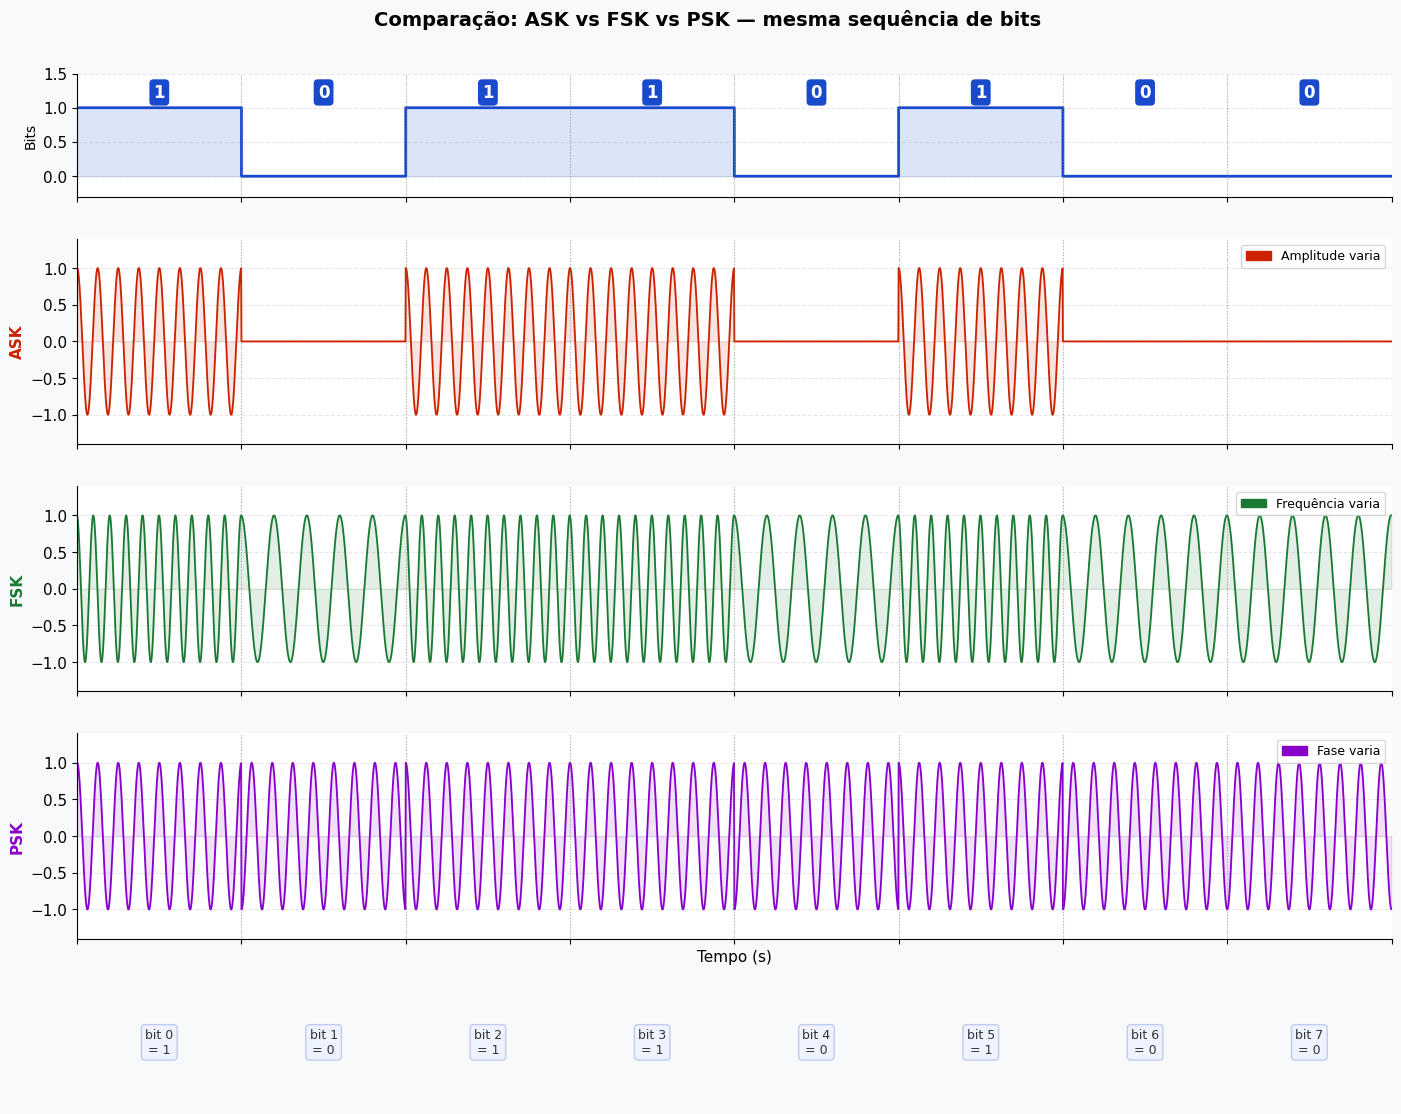

✅ Comparação gerada!


In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True,
                          gridspec_kw={'height_ratios': [0.6, 1, 1, 1, 0.6]})
fig.suptitle('Comparação: ASK vs FSK vs PSK — mesma sequência de bits',
             fontsize=14, fontweight='bold', y=1.01)

# Row 0 — bits
axes[0].step(t_total, data_signal, where='post', color='#1a4acc', linewidth=2)
axes[0].set_ylabel('Bits', fontsize=10)
axes[0].set_ylim(-0.3, 1.5)
axes[0].fill_between(t_total, data_signal, step='post', alpha=0.15, color='#1a4acc')
for i, b in enumerate(bits):
    axes[0].text(i + 0.5, 1.15, str(b), ha='center', fontsize=12, fontweight='bold',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='#1a4acc', edgecolor='none'))

# Row 1 — ASK
axes[1].plot(t_total, ask_signal, color='#cc2200', linewidth=1.3)
axes[1].fill_between(t_total, ask_signal, 0, alpha=0.12, color='#cc2200')
axes[1].set_ylabel('ASK', fontsize=11, color='#cc2200', fontweight='bold')
axes[1].set_ylim(-1.4, 1.4)
patch_ask = mpatches.Patch(color='#cc2200', label='Amplitude varia')
axes[1].legend(handles=[patch_ask], loc='upper right', fontsize=9)

# Row 2 — FSK
axes[2].plot(t_total, fsk_signal, color='#1a7a33', linewidth=1.3)
axes[2].fill_between(t_total, fsk_signal, 0, alpha=0.12, color='#1a7a33')
axes[2].set_ylabel('FSK', fontsize=11, color='#1a7a33', fontweight='bold')
axes[2].set_ylim(-1.4, 1.4)
patch_fsk = mpatches.Patch(color='#1a7a33', label='Frequência varia')
axes[2].legend(handles=[patch_fsk], loc='upper right', fontsize=9)

# Row 3 — PSK
axes[3].plot(t_total, bpsk_signal, color='#8800cc', linewidth=1.3)
axes[3].fill_between(t_total, bpsk_signal, 0, alpha=0.12, color='#8800cc')
axes[3].set_ylabel('PSK', fontsize=11, color='#8800cc', fontweight='bold')
axes[3].set_ylim(-1.4, 1.4)
patch_psk = mpatches.Patch(color='#8800cc', label='Fase varia')
axes[3].legend(handles=[patch_psk], loc='upper right', fontsize=9)

# Row 4 — bit label axis
axes[4].axis('off')
for i, b in enumerate(bits):
    axes[4].text(i + 0.5, 0.5, f'bit {i}\n= {b}', ha='center', va='center',
                 fontsize=9, color='#333',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#eef3ff', edgecolor='#c0ccee'))

# Bit boundaries on all signal rows
for ax in axes[:4]:
    for i in range(1, n_bits):
        ax.axvline(x=i * bit_duration, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

axes[3].set_xlabel('Tempo (s)', fontsize=11)
axes[4].set_xlim(0, n_bits)
plt.tight_layout()
plt.savefig('modulation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparação gerada!')

---
## 🌌 Diagramas de Constelação

O **diagrama de constelação** mostra os símbolos possíveis no plano complexo (**I × Q**).

- **I** (In-phase): componente real
- **Q** (Quadrature): componente imaginária

Cada ponto representa um símbolo. Quanto mais **afastados** os pontos, maior a imunidade a ruído.

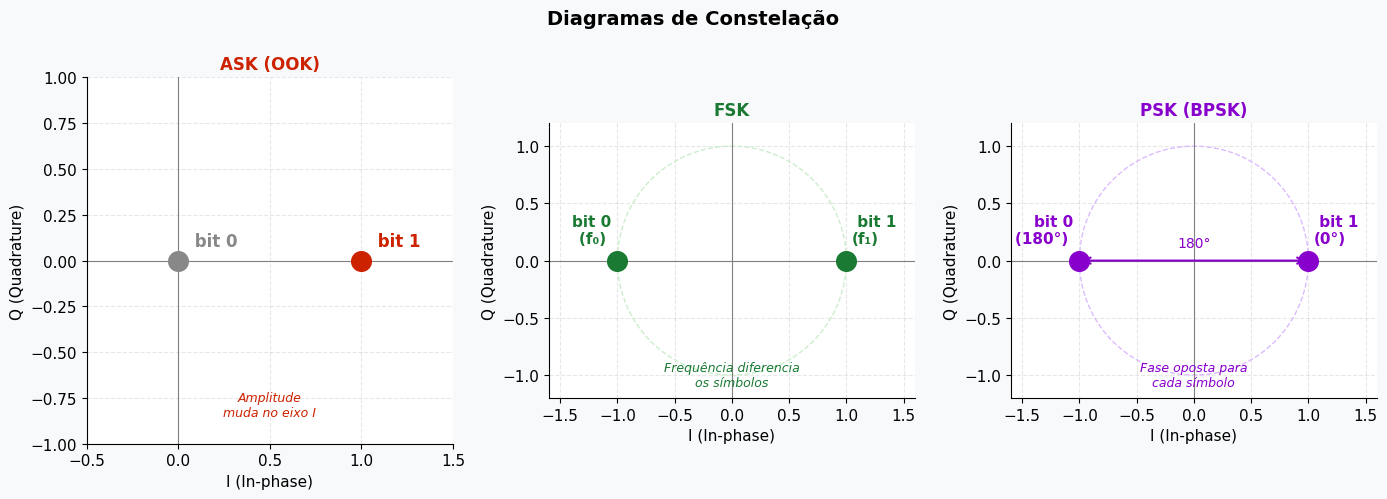

✅ Diagramas de constelação gerados!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Diagramas de Constelação', fontsize=14, fontweight='bold')

# ── ASK (OOK) ──
ax = axes[0]
ax.set_title('ASK (OOK)', fontsize=12, color='#cc2200', fontweight='bold')
# Bit 0: amplitude 0 → (0, 0);  Bit 1: amplitude 1 → (1, 0)
points_ask = [(0, 0, '0', '#888888'), (1, 0, '1', '#cc2200')]
for x, y, label, c in points_ask:
    ax.scatter(x, y, s=200, color=c, zorder=5)
    ax.annotate(f' bit {label}', (x, y), fontsize=12, color=c, fontweight='bold',
                xytext=(x + 0.06, y + 0.08))
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-1, 1)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('I (In-phase)')
ax.set_ylabel('Q (Quadrature)')
ax.set_aspect('equal')
ax.text(0.5, -0.85, 'Amplitude\nmuda no eixo I', ha='center', fontsize=9, color='#cc2200',
        style='italic')

# ── FSK ──
ax = axes[1]
ax.set_title('FSK', fontsize=12, color='#1a7a33', fontweight='bold')
# FSK é representado por duas portadoras separadas;
# no plano IQ cada frequência é um círculo unitário separado
theta = np.linspace(0, 2*np.pi, 200)
# Representação simplificada: dois pontos opostos em fase
ax.scatter(1, 0,   s=200, color='#1a7a33', zorder=5)
ax.scatter(-1, 0,  s=200, color='#1a7a33', zorder=5)
ax.annotate(' bit 1\n(f₁)', (1, 0),  fontsize=11, color='#1a7a33', fontweight='bold',
            xytext=(1.05, 0.15))
ax.annotate('bit 0\n(f₀) ', (-1, 0), fontsize=11, color='#1a7a33', fontweight='bold',
            ha='right', xytext=(-1.05, 0.15))
ax.plot(np.cos(theta), np.sin(theta), color='#cceecc', linewidth=1, linestyle='--')
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('I (In-phase)')
ax.set_ylabel('Q (Quadrature)')
ax.set_aspect('equal')
ax.text(0, -1.1, 'Frequência diferencia\nos símbolos', ha='center', fontsize=9,
        color='#1a7a33', style='italic')

# ── BPSK ──
ax = axes[2]
ax.set_title('PSK (BPSK)', fontsize=12, color='#8800cc', fontweight='bold')
ax.plot(np.cos(theta), np.sin(theta), color='#ddbbff', linewidth=1, linestyle='--')
ax.scatter(1, 0,   s=200, color='#8800cc', zorder=5)
ax.scatter(-1, 0,  s=200, color='#8800cc', zorder=5)
ax.annotate(' bit 1\n(0°)',   (1, 0),  fontsize=11, color='#8800cc', fontweight='bold',
            xytext=(1.05, 0.15))
ax.annotate('bit 0\n(180°) ', (-1, 0), fontsize=11, color='#8800cc', fontweight='bold',
            ha='right', xytext=(-1.05, 0.15))
# Phase arrow
ax.annotate('', xy=(-1, 0), xytext=(1, 0),
            arrowprops=dict(arrowstyle='<->', color='#8800cc', lw=1.5))
ax.text(0, 0.12, '180°', ha='center', fontsize=10, color='#8800cc')
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('I (In-phase)')
ax.set_ylabel('Q (Quadrature)')
ax.set_aspect('equal')
ax.text(0, -1.1, 'Fase oposta para\ncada símbolo', ha='center', fontsize=9,
        color='#8800cc', style='italic')

plt.tight_layout()
plt.savefig('constellations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Diagramas de constelação gerados!')

---
## 🔉 Efeito do Ruído nos Sinais

Vamos simular como cada técnica se comporta na presença de **ruído gaussiano (AWGN)**.

O **SNR (Signal-to-Noise Ratio)** mede a qualidade do sinal:

$$SNR_{dB} = 10 \log_{10}\left(\frac{P_{sinal}}{P_{ruído}}\right)$$

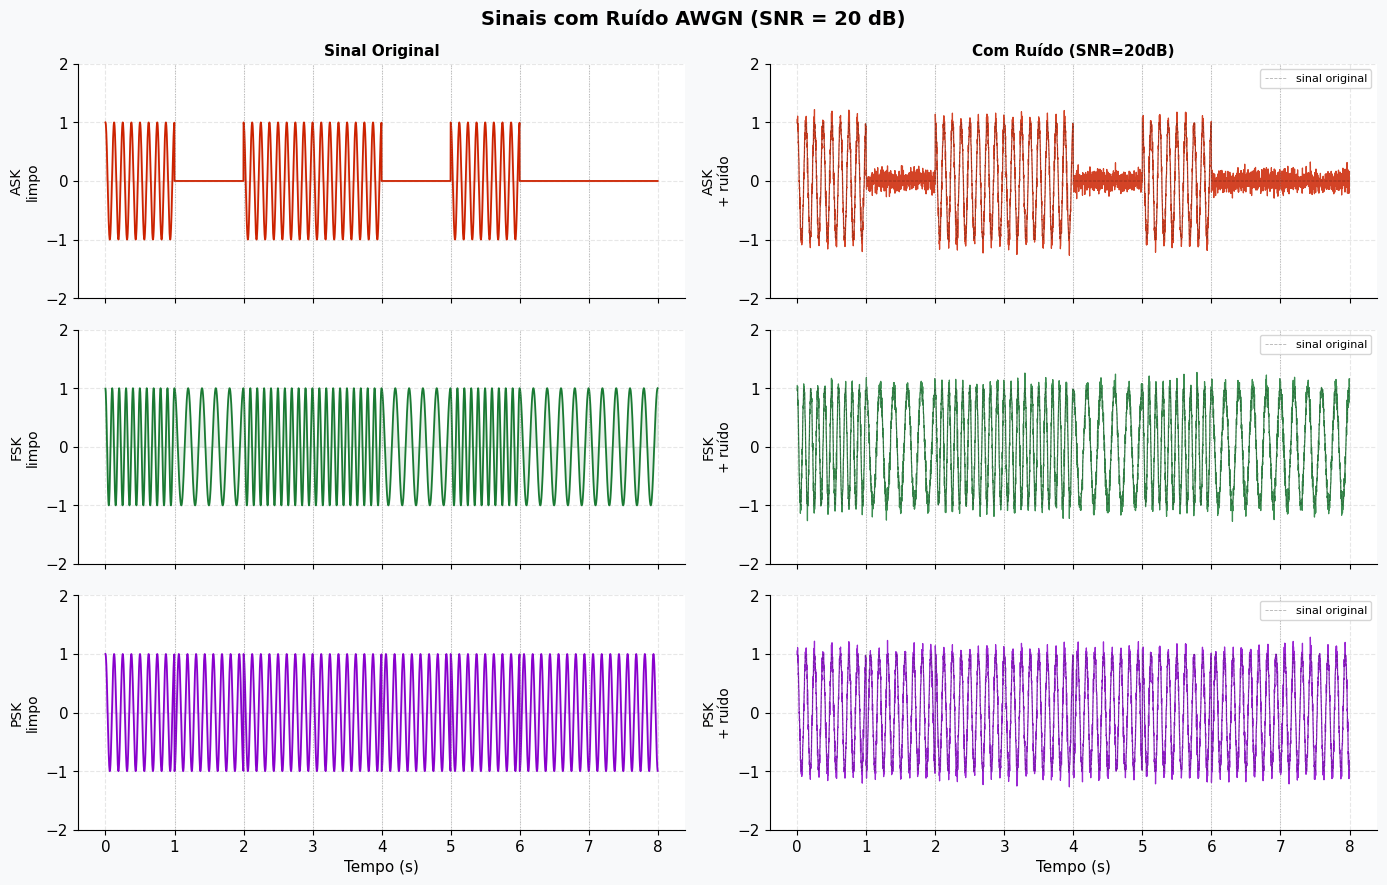

✅ Comparação com ruído gerada!


In [ ]:
# ── Adição de ruído AWGN ──────────────────────────────────────
np.random.seed(42)
snr_db = 10                          # SNR desejado em dB
snr_linear = 10 ** (snr_db / 10)
noise_power = 1 / snr_linear
noise = np.random.normal(0, np.sqrt(noise_power), len(t_total))

ask_noisy  = ask_signal  + noise
fsk_noisy  = fsk_signal  + noise
bpsk_noisy = bpsk_signal + noise

# ── Figura ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
fig.suptitle(f'Sinais com Ruído AWGN (SNR = {snr_db} dB)', fontsize=14, fontweight='bold')

pairs = [
    (ask_signal,  ask_noisy,  '#cc2200', 'ASK'),
    (fsk_signal,  fsk_noisy,  '#1a7a33', 'FSK'),
    (bpsk_signal, bpsk_noisy, '#8800cc', 'PSK'),
]

for row, (clean, noisy, color, label) in enumerate(pairs):
    axes[row][0].plot(t_total, clean, color=color, linewidth=1.3)
    axes[row][0].set_ylabel(f'{label}\nlimpo', fontsize=10)
    axes[row][0].set_ylim(-2, 2)
    axes[row][0].fill_between(t_total, clean, 0, alpha=0.1, color=color)

    axes[row][1].plot(t_total, noisy, color=color, linewidth=0.9, alpha=0.85)
    axes[row][1].plot(t_total, clean, color='black', linewidth=0.6, alpha=0.3, linestyle='--',
                      label='sinal original')
    axes[row][1].set_ylabel(f'{label}\n+ ruído', fontsize=10)
    axes[row][1].set_ylim(-2, 2)
    axes[row][1].legend(fontsize=8, loc='upper right')

    for col in range(2):
        for i in range(1, n_bits):
            axes[row][col].axvline(x=i, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)

axes[0][0].set_title('Sinal Original', fontsize=11, fontweight='bold')
axes[0][1].set_title(f'Com Ruído (SNR={snr_db}dB)', fontsize=11, fontweight='bold')
for col in range(2):
    axes[2][col].set_xlabel('Tempo (s)', fontsize=11)

plt.tight_layout()
plt.savefig('modulation_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparação com ruído gerada!')

---
## 📋 Resumo e Tabela Comparativa

| Característica | ASK | FSK | PSK |
|----------------|-----|-----|-----|
| **Parâmetro modificado** | Amplitude | Frequência | Fase |
| **Complexidade** | Baixa | Média | Alta |
| **Imunidade a ruído** | Baixa | Média | Alta |
| **Largura de banda** | Estreita | Larga | Estreita |
| **Eficiência espectral** | Média | Baixa | Alta |
| **Amplitude constante?** | ❌ Não | ✅ Sim | ✅ Sim |
| **Aplicações típicas** | RFID, IR remoto | Modems, rádio FM | Wi-Fi, 4G/5G, satélite |

---

### 🧭 Quando usar cada uma?

- **ASK** → ambientes controlados, curta distância, baixo custo (ex: controle remoto)
- **FSK** → canais com variação de amplitude (ex: linhas telefônicas, telemetria)
- **PSK** → comunicações digitais modernas que exigem eficiência e robustez

> 📌 Versões avançadas como **QAM** combinam ASK + PSK para maximizar a taxa de dados.